<a href="https://colab.research.google.com/github/rabia28k/Manav-Yapay-Zeka-YOLOv8/blob/main/Manav_Yapi_Egitim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Kütüphane Kurulumu
!pip install ultralytics

from ultralytics import YOLO
from google.colab import drive
import os

# 2. Drive Bağlantısı
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Drive yolunu buraya yazıyoruz
drive_yolu = '/content/drive/MyDrive/MEYVE_SEBZE_FINAL_DATASET'

yaml_icerigi = f"""
path: {drive_yolu}
train: train/images
val: valid/images
test: test/images

nc: 5
names: ['patlican', 'muz', 'patates', 'havuc', 'salatalik']
"""

# Dosyayı Colab hafızasına kaydet
with open("/content/data_config.yaml", "w") as f:
    f.write(yaml_icerigi)

print("✅ data_config.yaml dosyası oluşturuldu.")

✅ data_config.yaml dosyası oluşturuldu.


In [3]:
# Modeli yükle (Nano versiyonu en hızlısıdır)
model = YOLO('yolov8n.pt')

# Eğitimi başlat
model.train(
    data='/content/data_config.yaml',
    epochs=50,    # 50 tur dönecek (Manav robotu iyice öğrensin)
    imgsz=640,    # Resim kalitesi
    device=0,     # GPU (Ekran kartı) kullan
    name='meyve_sebze_modelim'
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=meyve_sebze_modelim, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dcbca1c9070>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [4]:
import os

# Veri setinde dengesizlik var mı diye bi kontrol etmem lazım.
# Hangi meyveden kaç tane resim etiketlemişim bi bakalım:

labels_path = '/content/drive/MyDrive/MEYVE_SEBZE_FINAL_DATASET/train/labels'
meyveler = ['patlican', 'muz', 'patates', 'havuc', 'salatalik']
sayac = {i: 0 for i in range(len(meyveler))}

# Label dosyalarını tek tek tara, sınıfları topla
for f_name in os.listdir(labels_path):
    with open(os.path.join(labels_path, f_name), 'r') as f:
        for satir in f:
            cls_id = int(satir.split()[0])
            sayac[cls_id] += 1

print("--- Elimdeki Eğitim Verisi Sayıları ---")
for i, ad in enumerate(meyveler):
    print(f"{ad}: {sayac[i]} tane")

# Not: Patates ve Patlıcan sayıları iyi, model bunları rahat kapar.
# Eğer hata oranı yüksek çıkarsa buralara ekleme yapmak gerekebilir.

--- Elimdeki Eğitim Verisi Sayıları ---
patlican: 1292 tane
muz: 2088 tane
patates: 24646 tane
havuc: 1970 tane
salatalik: 1455 tane


veri dengesizliğini düzelt



0: 640x640 1 muz, 14.2ms
1: 640x640 1 salatalik, 14.2ms
2: 640x640 1 patlican, 14.2ms
3: 640x640 2 muzs, 14.2ms
4: 640x640 1 patlican, 14.2ms
Speed: 4.9ms preprocess, 14.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


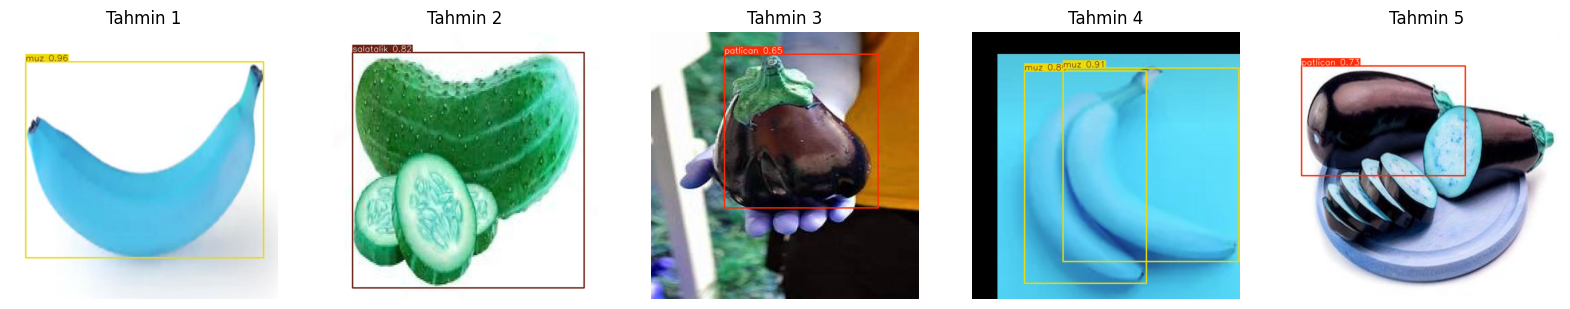

In [5]:
import glob
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

# 1. En iyi modelimizi yükleyelim
model_path = '/content/runs/detect/meyve_sebze_modelim/weights/best.pt'
model = YOLO(model_path)

# 2. Test klasöründeki resim yollarını alalım
test_images = glob.glob('/content/drive/MyDrive/MEYVE_SEBZE_FINAL_DATASET/test/images/*.jpg')

# 3. Rastgele 5 tane resim seçelim (Her seferinde farklı gelsin)
random_test_images = random.sample(test_images, 5)

# 4. Tahmin yapalım
results = model.predict(source=random_test_images, conf=0.5, save=True)

# 5. Sonuçları ekranda yan yana gösterelim
plt.figure(figsize=(20, 10))
for i, res in enumerate(results):
    # Tahmin edilen resmin kaydedildiği yolu bul (Genelde runs/detect/predictX/...)
    # Ama biz direkt orijinal resim üzerine çizilmiş hali yerine sonuçtan görelim
    img = res.plot() # Tahmin kutuları çizilmiş hali

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"Tahmin {i+1}")
    plt.axis('off')

plt.show()

# Kendi notum: Patates baskın olsa da bakalım salatalığa patates diyecek mi?
# Eğer doğru biliyorsa modelin 'feature extraction' (özellik çıkarma) yeteneği sağlam demektir.